In [99]:
import pandas as pd
from sklearn.svm import SVR
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import pickle
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

optimized_x_reg = np.load('optimized_x_reg.npy')
optimized_x_clf = np.load('optimized_x_clf.npy')
y_reg = np.load('y_reg.npy')
classification_y = np.load('classification_y.npy')
clf_feature_names = np.load('clf_feature_names.npy')
reg_feature_names = np.load('reg_feature_names.npy')

le = pickle.load(open('label_encoder.pkl', 'rb'))


In [62]:
print("Regression selected features: study_hours_per_day, ai_usage_time_minutes, ai_generated_content_percentage, ai_prompts_per_week, last_exam_score, assignment_scores_avg, attendance_percentage, concept_understanding_score, study_consistency_index, improvement_rate, sleep_hours, social_media_hours, tutoring_hours "
    "\nClassification selected features: study_hours_per_day, ai_usage_time_minutes, ai_generated_content_percentage, ai_prompts_per_week, "
    "last_exam_score, assignment_scores_avg, attendance_percentage, "
    "concept_understanding_score, study_consistency_index, "
    "improvement_rate")

Regression selected features: study_hours_per_day, ai_usage_time_minutes, ai_generated_content_percentage, ai_prompts_per_week, last_exam_score, assignment_scores_avg, attendance_percentage, concept_understanding_score, study_consistency_index, improvement_rate, sleep_hours, social_media_hours, tutoring_hours 
Classification selected features: study_hours_per_day, ai_usage_time_minutes, ai_generated_content_percentage, ai_prompts_per_week, last_exam_score, assignment_scores_avg, attendance_percentage, concept_understanding_score, study_consistency_index, improvement_rate


Machine Learning Techniques (Supervised):

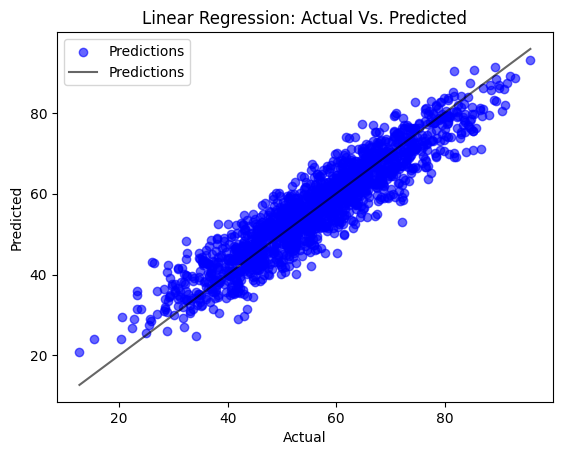

C:\Users\teyte\AppData\Local\Temp\ipykernel_65292\3129373563.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Class')


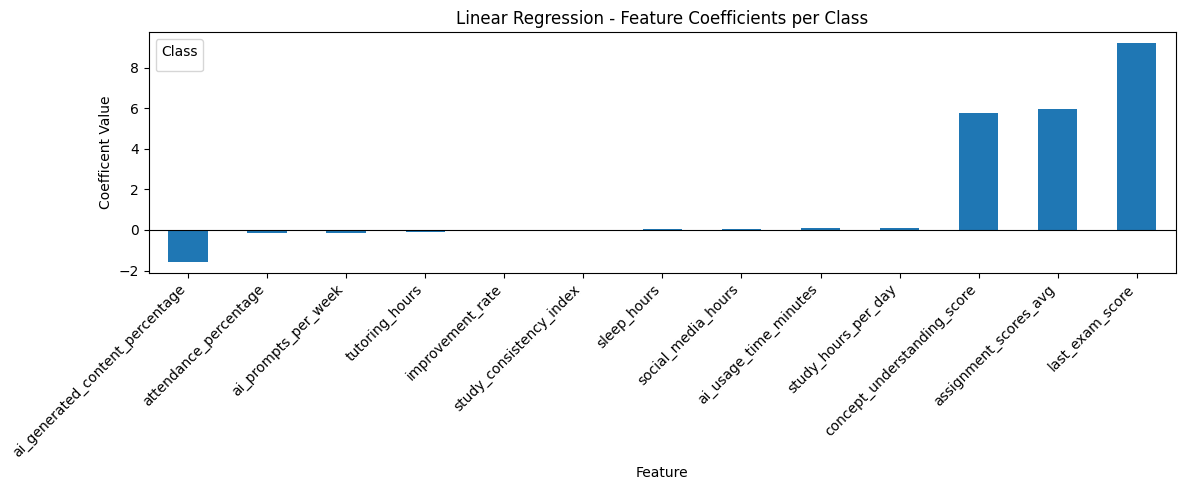

In [ ]:

#Linear Regression
linear_Reg = LinearRegression()
x_train, x_test, y_train, y_test = train_test_split(optimized_x_reg, y_reg, test_size = 0.2, random_state=10)
linear_Model = linear_Reg.fit(x_train, y_train)
y_pred_linear = linear_Model.predict(x_test)

plt.scatter(y_test, y_pred_linear, color='blue', alpha=0.6, label='Predictions')

min_val = min(y_test.min(), y_pred_linear.min())
max_val = max(y_test.max(), y_pred_linear.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', alpha=0.6, label='Predictions')
plt.title('Linear Regression: Actual Vs. Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()
plt.show()

coef_series = pd.Series(linear_Model.coef_, index=reg_feature_names).sort_values()

coef_series.T.plot(kind='bar', figsize=(12, 5))
plt.title('Linear Regression - Feature Coefficients')
plt.xlabel('Feature')
plt.ylabel('Coefficent Value')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Class')
plt.tight_layout()
plt.show()



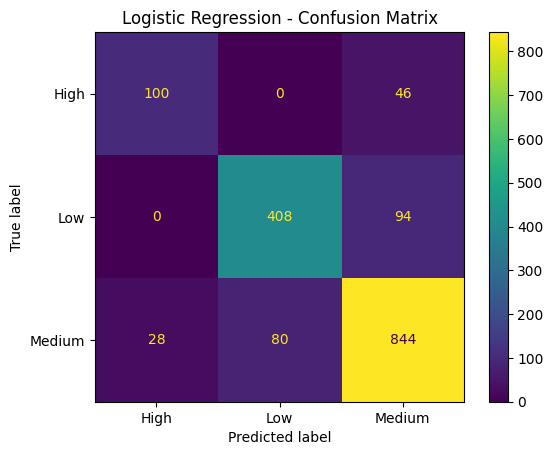

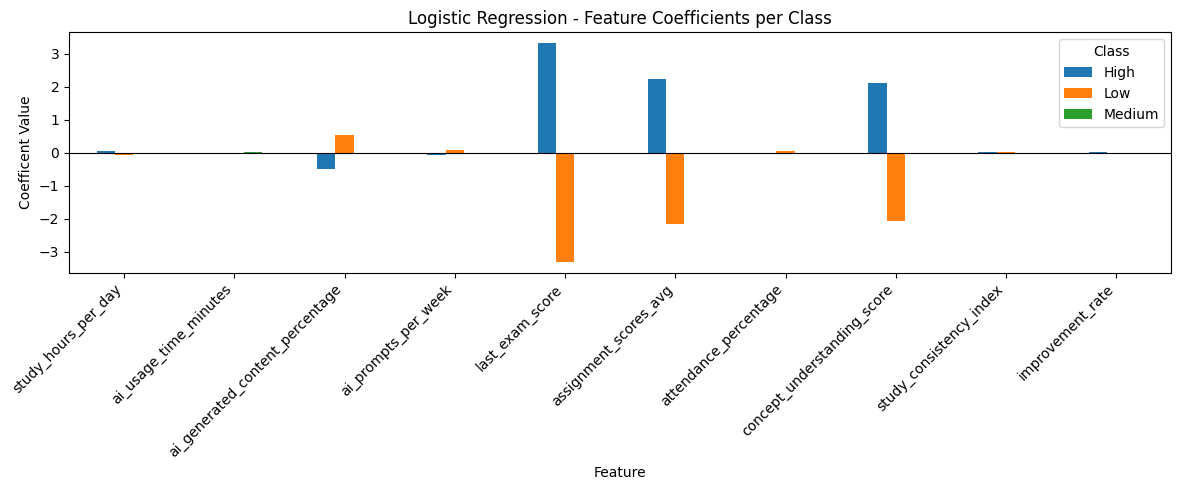

In [ ]:
#Logistic Regression
class_x_train, class_x_test, class_y_train, class_y_test = train_test_split(optimized_x_clf, classification_y, test_size=0.2, random_state=10)
log_Reg = LogisticRegression(max_iter=5000)
log_Model = log_Reg.fit(class_x_train, class_y_train)
y_pred_log = log_Reg.predict(class_x_test)

ConfusionMatrixDisplay.from_estimator(log_Model, class_x_test, class_y_test, display_labels=le.classes_)
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

coef_df = pd.DataFrame(log_Model.coef_, columns=clf_feature_names, index=le.classes_)

coef_df.T.plot(kind='bar', figsize=(12, 5))
plt.title('Logistic Regression - Feature Coefficients per Class')
plt.xlabel('Feature')
plt.ylabel('Coefficent Value')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Class')
plt.tight_layout()
plt.show()

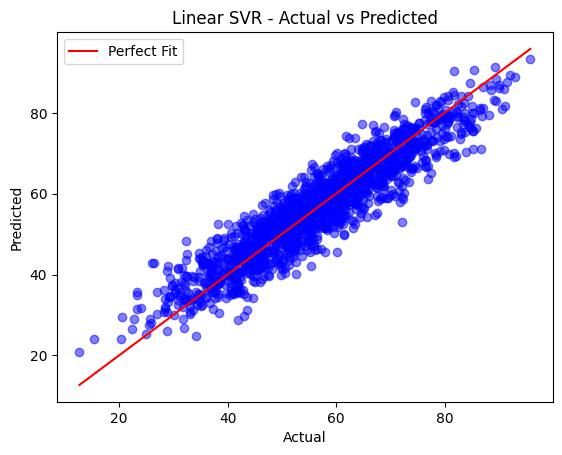

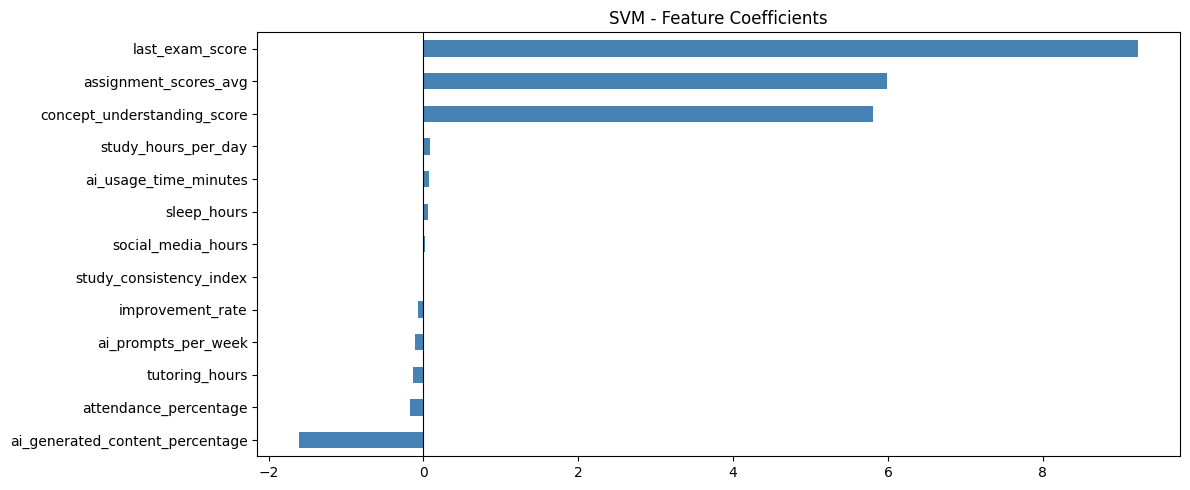

In [79]:

#Support Vector Machines (SVM)
svm_Model = SVR(kernel='linear', epsilon=0.5)
svm_Model.fit(x_train, y_train)
y_pred_svm = svm_Model.predict(x_test)

plt.scatter(y_test, y_pred_svm, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', label='Perfect Fit')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title("Linear SVR - Actual vs Predicted")
plt.legend()
plt.show()

coef_series = pd.Series(svm_Model.coef_.flatten(), index=reg_feature_names).sort_values()

coef_series.plot(kind='barh', figsize=(12, 5), color='steelblue')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title("SVM - Feature Coefficients")
plt.tight_layout()
plt.show()

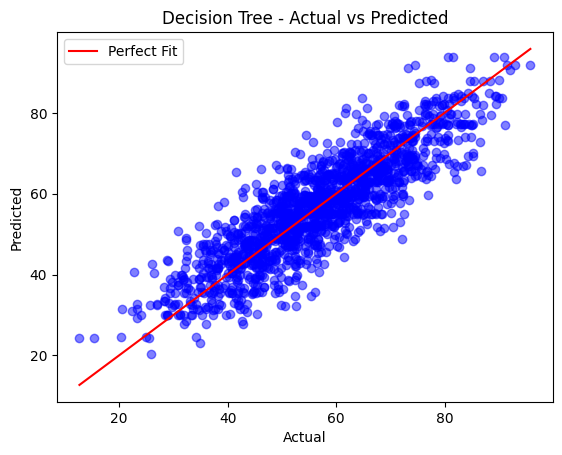

In [74]:
#Decision Trees
#tiffany
dt_model = DecisionTreeRegressor(max_depth=10, random_state=10, min_samples_split=3)
dt_model.fit(x_train, y_train)
y_pred_dt = dt_model.predict(x_test)

plt.scatter(y_test, y_pred_dt, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', label='Perfect Fit')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title("Decision Tree - Actual vs Predicted")
plt.legend()
plt.show()


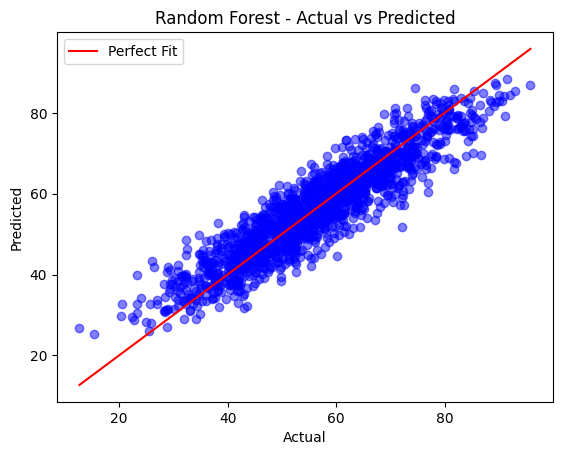

In [48]:
#Random Forests
#tiffany
rf_model = RandomForestRegressor(n_estimators=200, random_state=10)
rf_model.fit(x_train, y_train)
y_pred_rt = rf_model.predict(x_test)

plt.scatter(y_test, y_pred_rt, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', label='Perfect Fit')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title("Random Forest - Actual vs Predicted")
plt.legend()
plt.show()

Optimal K value (Elbow Method): 20


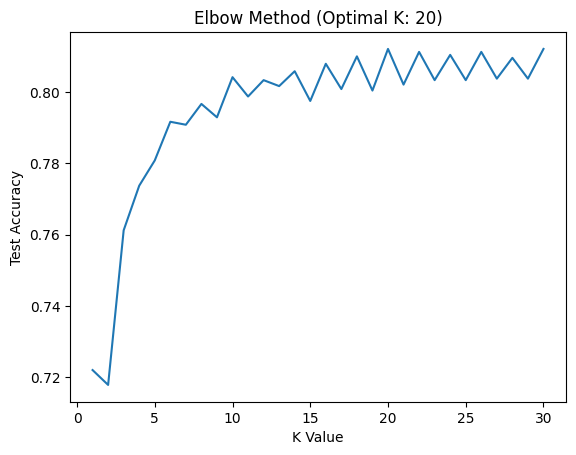

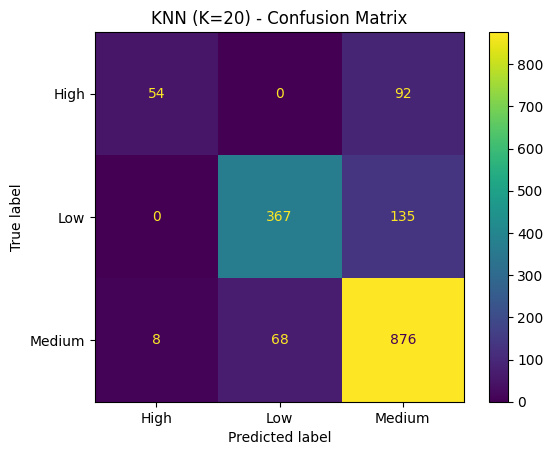

In [56]:
#k-Nearest Neighbors (k-NN)
def elbow_method(x, y, k_range):
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
    test_scores=[]
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(x_train, y_train)
        test_scores.append(accuracy_score(y_test, knn.predict(x_test)))
        
    optimal_k = k_range[np.argmax(test_scores)]
    print(f"Optimal K value (Elbow Method): {optimal_k}")
    
    plt.plot(k_range, test_scores)
    plt.xlabel('K Value')
    plt.ylabel('Test Accuracy')
    plt.title(f'Elbow Method (Optimal K: {optimal_k})')
    plt.show()

elbow_method(optimized_x_clf, classification_y, range(1, 31))
knn = KNeighborsClassifier(n_neighbors=20, metric='euclidean')
knn.fit(class_x_train, class_y_train)
y_pred_knn = knn.predict(class_x_test)

ConfusionMatrixDisplay.from_estimator(knn, class_x_test, class_y_test, display_labels=le.classes_)
plt.title("KNN (K=20) - Confusion Matrix")
plt.show()

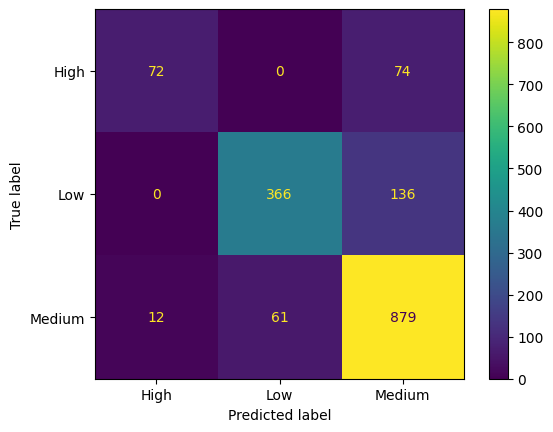

In [59]:
#Naive Bayes
gnb = GaussianNB()
gnb.fit(class_x_train, class_y_train)
y_pred_gnb = gnb.predict(class_x_test)
ConfusionMatrixDisplay.from_estimator(gnb, class_x_test, class_y_test, display_labels=le.classes_)

In [51]:
#Machine Learning Techniques (Unsupervised):


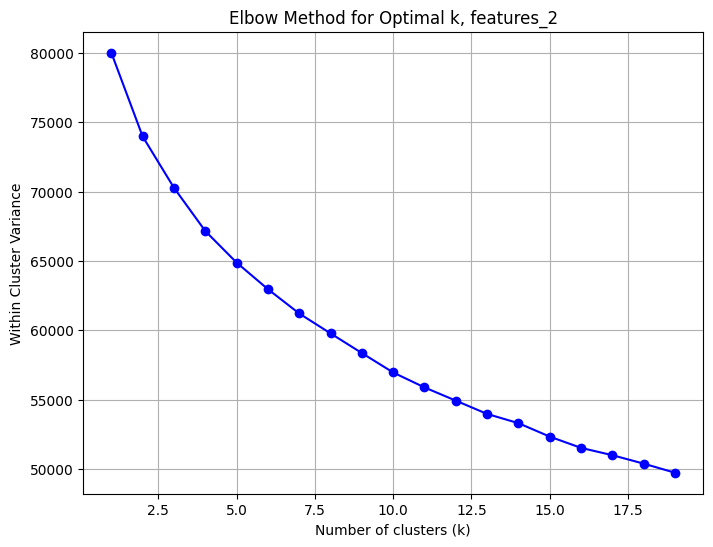

Optimal number of clusters (k): 2


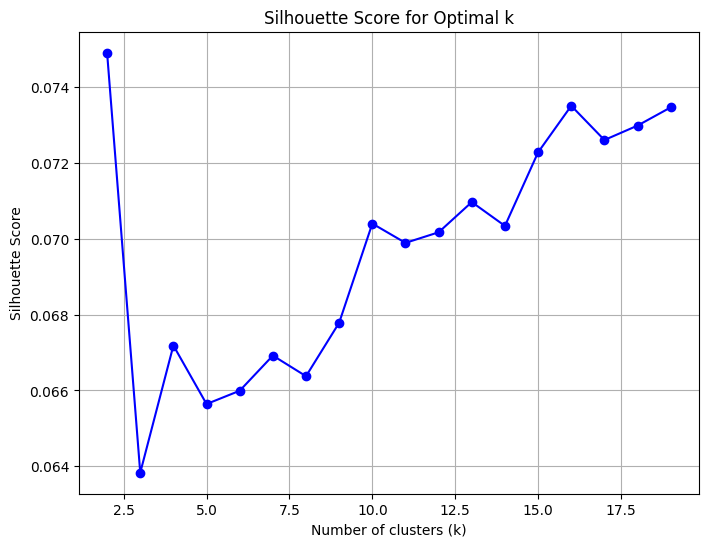

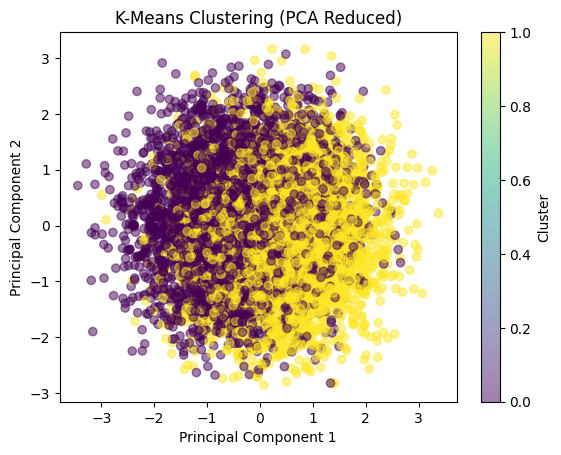

Variance explained: [0.10577298 0.10340683]
                                      PC1       PC2
ai_generated_content_percentage  0.534348  0.027725
attendance_percentage            0.429978 -0.181195
concept_understanding_score      0.414611 -0.146334
improvement_rate                 0.322353  0.635274
ai_usage_time_minutes            0.212508 -0.375523
assignment_scores_avg            0.204781  0.214620
last_exam_score                  0.147965  0.049814
study_hours_per_day              0.109208 -0.508064
ai_prompts_per_week             -0.026913 -0.305799
study_consistency_index         -0.363508  0.014526


In [ ]:
#k-Means Clustering + PCA
#tiffany 
#Elbow Method
Within_cluster = []
N_itr = 20

for k in range(1, N_itr):
    kmeans = KMeans(n_clusters=k, random_state=10)
    kmeans.fit(optimized_x_clf)
    Within_cluster.append(kmeans.inertia_)

#Elbow Method Graph
plt.figure(figsize=(8, 6))
plt.plot(range(1, N_itr), Within_cluster, marker='o', color='b')
plt.title('Elbow Method for Optimal k, features_2')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Within Cluster Variance')
plt.grid(True)
plt.show()

#Silhouette Method Features_1
Silhouette_scores = []
N_itr = 20
k_values = list(range(2, N_itr))

for k in range(2, N_itr):
    kmeans = KMeans(n_clusters=k, random_state=10)
    labels = kmeans.fit_predict(optimized_x_clf)
    score = silhouette_score(optimized_x_clf, labels)
    Silhouette_scores.append(score)

#Optimal k
optimal_k = k_values[np.argmax(Silhouette_scores)]
print(f"Optimal number of clusters (k): {optimal_k}")

#Silhouette Score graph
plt.figure(figsize=(8,6))
plt.plot(range(2, N_itr), Silhouette_scores, marker='o', color='b')
plt.title("Silhouette Score for Optimal k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

#KMeans
kmeans = KMeans(n_clusters=optimal_k, random_state=20, n_init='auto')
kmeans.fit(optimized_x_clf)

#Plot
pca = PCA(n_components=2)
x_pca = pca.fit_transform(optimized_x_clf)

plt.scatter(x_pca[:, 0], x_pca[:, 1], c=kmeans.labels_, cmap='viridis', alpha=0.5)
plt.title('K-Means Clustering (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.show()

print("Variance explained:", pca.explained_variance_ratio_)

# See which features contribute most to each PC
pc_df = pd.DataFrame(pca.components_, 
                     columns=clf_feature_names,
                     index=['PC1', 'PC2'])
print(pc_df.T.sort_values('PC1', ascending=False))

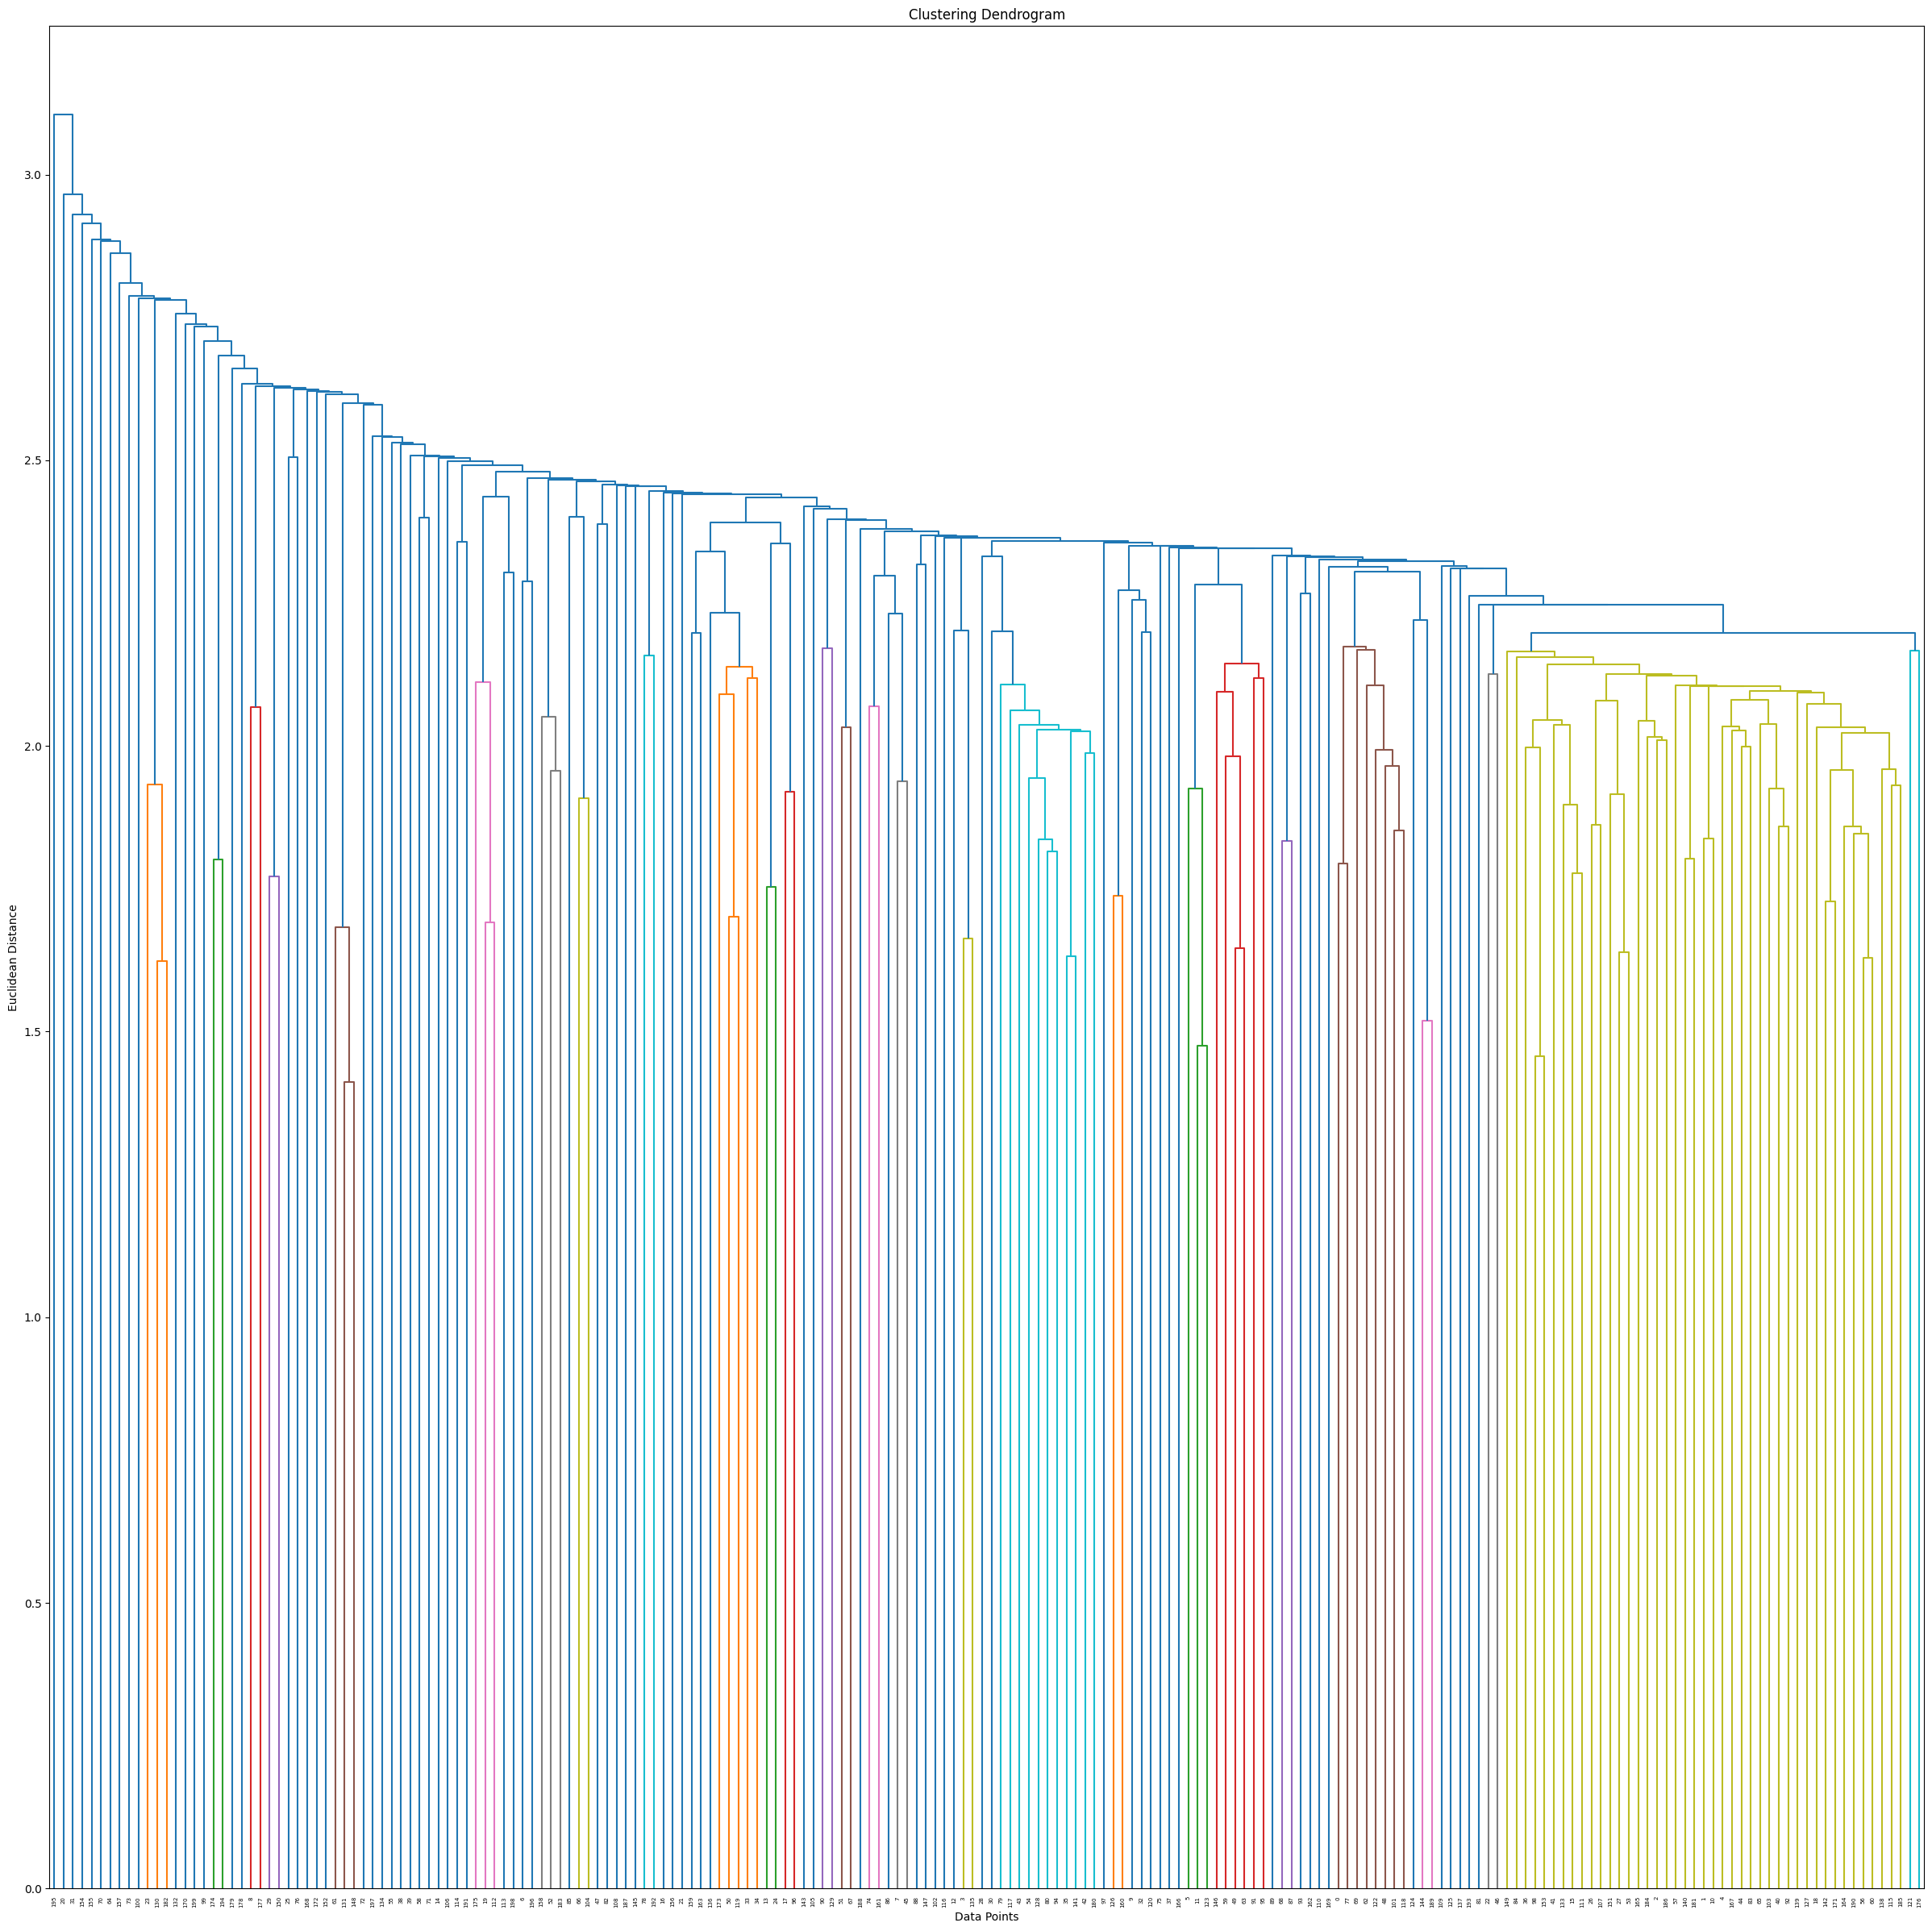

C:\Users\teyte\AppData\Local\Temp\ipykernel_65292\1028857775.py:17: RuntimeWarning: Mean of empty slice
  sample[agg_labels == k].mean(axis=0)
c:\Users\teyte\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


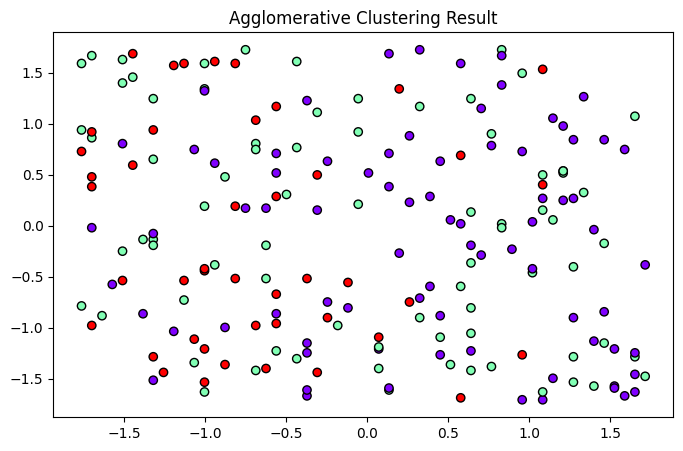

In [104]:
#Hierarchical Clustering
#Dendrogram
np.random.seed(42)
sample = optimized_x_clf[np.random.choice(len(optimized_x_clf), 200, replace=False)]
plt.figure(figsize=(30, 30))
sch.dendrogram(sch.linkage(sample))
plt.title("Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

k = 3
agg_clustering = AgglomerativeClustering(n_clusters=k, linkage='ward')
agg_labels = agg_clustering.fit_predict(sample)

centroid = np.array([
    sample[agg_labels == k].mean(axis=0)
    for i in range(k)
])

#Plot clusters
plt.figure(figsize=(8, 5))
plt.scatter(sample[:, 0], sample[:, 1], c=agg_labels, cmap='rainbow', edgecolors='k')
plt.scatter(centroid[:, 0], centroid[:, 1], c='red', marker='x', s=200, label='Centroids')
plt.title("Agglomerative Clustering Result")
plt.show()

In [55]:
#Deep Learning:
#both of us? 
